### FASE 3: División de Datos 

| Vamos a extraer caracteristicas por cada registro

Importamos librerias

In [62]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
tqdm.pandas()
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pyswarms as ps
from pyswarms.utils.functions import single_obj as fx
import seaborn as sns
import matplotlib.pyplot as plt




✅ División completada:


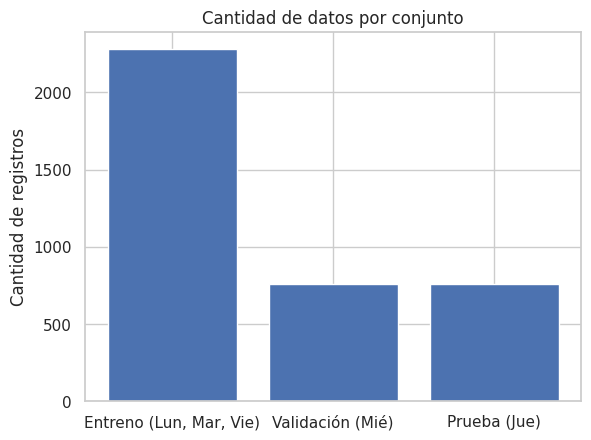

In [63]:
df = pd.read_csv('completo_clusters_con_features.csv')

df_model = df.copy()

le = LabelEncoder()
df_model['Direccion'] = le.fit_transform(df_model['Direccion'])


features = [
    'Total_Vehiculos', 'Tiempo_Medio_s', 'Ocupacion_Espacial_%', 
    'Hora_Minutos', 'Dia_Semana', 'Direccion', 'cluster', 
    'Es_Hora_Pico', 'Total_Vehiculos_lag1', 'Ocupacion_lag1', 
    'Media_Movil_3ciclos', 'Tendencia_Vehiculos', 'Saturacion_Actual',
    'Periodo_Dia', 'Cluster_Hora_Pico'  
]


entreno_data = df_model[df_model['Dia_Semana'].isin([1, 2,5])]
val_data   = df_model[df_model['Dia_Semana'] == 3]
prueba_data  = df_model[df_model['Dia_Semana'] == 4]


X_entreno, y_entreno = entreno_data[features], entreno_data['Tiempo_Optimo_Target']
X_val, y_val     = val_data[features], val_data['Tiempo_Optimo_Target']
X_prueba, y_prueba   = prueba_data[features], prueba_data['Tiempo_Optimo_Target']

print(f"✅ División completada:")

labels = [
    'Entreno (Lun, Mar, Vie)',
    'Validación (Mié)',
    'Prueba (Jue)'
]

sizes = [
    X_entreno.shape[0],
    X_val.shape[0],
    X_prueba.shape[0]
]

plt.figure()
plt.bar(labels, sizes)
plt.ylabel('Cantidad de registros')
plt.title('Cantidad de datos por conjunto')
plt.show()

### FASE 5: Optimización con PSO

In [64]:

def pso_rf_optimization(X_train, y_train, X_val, y_val):
    """
    Usa PSO para optimizar hiperparámetros de Random Forest
    """
    
    def fitness_function(particles):
        """
        Función objetivo para PSO
        particles: matriz donde cada fila es una partícula (configuración)
        """
        scores = []
        
        for particle in particles:
            n_estimators = int(particle[0])
            max_depth = int(particle[1]) if particle[1] > 0 else None
            min_samples_split = int(particle[2])
            min_samples_leaf = int(particle[3])
            max_features_idx = int(particle[4])
            
            max_features_options = ['sqrt', 'log2', None]
            max_features = max_features_options[max_features_idx]
            
            rf = RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                max_features=max_features,
                random_state=42,
                n_jobs=-1
            )
            
            try:
                rf.fit(X_train, y_train)
                y_pred = rf.predict(X_val)
                
                mse = mean_squared_error(y_val, y_pred)
                scores.append(mse)
            except:
                
                scores.append(1e10)
        
        return np.array(scores)
    
    lb = [50, 0, 2, 1, 0]      # Lower bounds
    ub = [300, 30, 20, 10, 2]  # Upper bounds
    bounds = (lb, ub)
    
    options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}  
    optimizer = ps.single.GlobalBestPSO(
        n_particles=10,      # Número de partículas
        dimensions=5,        # Dimensiones (5 hiperparámetros)
        options=options,
        bounds=bounds
    )
    
    print("Iniciando optimización PSO...")
    best_cost, best_pos = optimizer.optimize(fitness_function, iters=20)
    
    best_params = {
        'n_estimators': int(best_pos[0]),
        'max_depth': int(best_pos[1]) if best_pos[1] > 0 else None,
        'min_samples_split': int(best_pos[2]),
        'min_samples_leaf': int(best_pos[3]),
        'max_features': ['sqrt', 'log2', None][int(best_pos[4])]
    }
    
    return best_params, best_cost

best_params, best_cost = pso_rf_optimization(X_entreno, y_entreno, X_val, y_val)

print("\n=== MEJORES HIPERPARÁMETROS ENCONTRADOS POR PSO ===")
print(best_params)
print(f"Mejor MSE: {best_cost:.3f}")

2026-01-13 14:01:51,540 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


Iniciando optimización PSO...


pyswarms.single.global_best:   0%|          |0/20

pyswarms.single.global_best: 100%|██████████|20/20, best_cost=0.407
2026-01-13 14:04:29,180 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.40704812040452776, best pos: [228.1191055   25.34317283   5.8003744    1.87265257   0.60752423]



=== MEJORES HIPERPARÁMETROS ENCONTRADOS POR PSO ===
{'n_estimators': 228, 'max_depth': 25, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Mejor MSE: 0.407


### FASE 6: Modelo Random Forest Optimizado

In [65]:
rf_optimizado = RandomForestRegressor(
    n_estimators=291,
    max_depth=13,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.7,
    min_impurity_decrease=0.002014949130589203,
    max_samples=0.8487885713440779,
    random_state=42,
    n_jobs=-1
)

rf_optimizado.fit(X_entreno, y_entreno)
y_val_pred_opt = rf_optimizado.predict(X_val)
mae_opt = mean_absolute_error(y_val, y_val_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_val, y_val_pred_opt))
r2_opt = r2_score(y_val, y_val_pred_opt)


### FASE 7: Evaluación Final 


In [66]:
y_test_pred = rf_optimizado.predict(X_prueba)

mae_test = mean_absolute_error(y_prueba, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_prueba, y_test_pred))
r2_test = r2_score(y_prueba, y_test_pred)
mape_test = np.mean(np.abs((y_prueba - y_test_pred) / y_prueba)) * 100

print("\n=== EVALUACIÓN FINAL EN TEST SET ===")
print(f"MAE: {mae_test:.3f} segundos")
print(f"RMSE: {rmse_test:.3f} segundos")
print(f"R²: {r2_test:.4f}")
print(f"MAPE: {mape_test:.2f}%")



=== EVALUACIÓN FINAL EN TEST SET ===
MAE: 0.025 segundos
RMSE: 0.052 segundos
R²: 1.0000
MAPE: 0.09%


### FASE 8: Prediccion de tiempos verdes

In [67]:
def analizar_tiempos_optimos_por_direccion(test_data, y_test_pred):

    test_data = test_data.copy()
    test_data['Tiempo_Predicho'] = y_test_pred
    
    print("\n" + "="*60)
    print("ANÁLISIS DE TIEMPOS ÓPTIMOS POR DIRECCIÓN")
    print("="*60 + "\n")
  
    resultados = {}
    
    for direccion in sorted(test_data['Direccion'].unique()):
        datos_dir = test_data[test_data['Direccion'] == direccion]['Tiempo_Predicho']
        
        tiempo_promedio = datos_dir.mean()
        tiempo_min = datos_dir.min()
        tiempo_max = datos_dir.max()
        tiempo_final = round(tiempo_promedio)
        
        diferencia = tiempo_final - 33
        porcentaje = (diferencia / 33) * 100
        
        resultados[f'direccion_{direccion + 1}'] = tiempo_final
       
        print(f"Dirección {direccion + 1}:")
        print(f"• Tiempo recomendado: {tiempo_final} segundos")
        print(f"• Rango predicho: [{tiempo_min:.1f}s - {tiempo_max:.1f}s]")
        print(f"• vs Baseline (33s): {diferencia:+d}s ({porcentaje:+.1f}%)")
        print()
    
   
    return resultados


config_sumo = analizar_tiempos_optimos_por_direccion(prueba_data, y_test_pred)

# print(config_sumo)


ANÁLISIS DE TIEMPOS ÓPTIMOS POR DIRECCIÓN

Dirección 1:
• Tiempo recomendado: 25 segundos
• Rango predicho: [20.0s - 35.5s]
• vs Baseline (33s): -8s (-24.2%)

Dirección 2:
• Tiempo recomendado: 26 segundos
• Rango predicho: [20.0s - 35.5s]
• vs Baseline (33s): -7s (-21.2%)

Dirección 3:
• Tiempo recomendado: 32 segundos
• Rango predicho: [22.0s - 38.6s]
• vs Baseline (33s): -1s (-3.0%)

Dirección 4:
• Tiempo recomendado: 27 segundos
• Rango predicho: [20.0s - 37.5s]
• vs Baseline (33s): -6s (-18.2%)

